# Pipeline de Clusterização de Clientes - Olist
Este notebook executa o pipeline completo de segmentação de clientes utilizando PCA para redução de dimensionalidade, seguido pelos algoritmos K-Means e GMM.

In [21]:
# Configuração para recarregar os arquivos .py automaticamente caso você os altere
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Importando apenas o motor de processamento e modelagem no início
from src.processamento import carregar_e_agregar_dados, tratar_e_padronizar
from src.modelagem import rodar_kmeans, rodar_gmm, comparar_modelos, analisar_perfis

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Passo 1: Consolidação dos Dados
Carregando os arquivos brutos da pasta `dados/` e agregando as informações por cliente único (`customer_unique_id`).

In [22]:
caminho_dados = 'dados/'
df_clientes = carregar_e_agregar_dados(caminho_dados)

print(f"Total de clientes unificados na base: {df_clientes.shape[0]}")
df_clientes.head()

Total de clientes unificados na base: 94990


,customer_unique_id,recencia,frequencia,monetario,parcelas_medias,pct_boleto,pct_cartao_credito,frete_total,review_medio,escreveu_comentario,tempo_entrega_medio,pct_compras_fds,is_sudeste,peso_medio_produtos,qtd_itens_total,gasto_casa_decoracao,gasto_saude_beleza,gasto_esporte_lazer,gasto_tecnologia,gasto_moda_acessorios
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90,8.0,0.0,1.0,12.00,5.0,1.0,6.0,0.0,1,1500.0,1.0,129.9,0.0,0.0,0.00,0.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19,1.0,0.0,1.0,8.29,4.0,0.0,3.0,0.0,1,375.0,1.0,0.0,18.9,0.0,0.00,0.0
2,0000f46a3911fa3c0805444483337064,542,1,86.22,8.0,0.0,1.0,17.22,3.0,0.0,25.0,0.0,0,1500.0,1.0,0.0,0.0,0.0,0.00,0.0
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62,4.0,0.0,1.0,17.63,4.0,1.0,20.0,0.0,0,150.0,1.0,0.0,0.0,0.0,25.99,0.0
4,0004aac84e0df4da2b147fca70cf8255,293,1,196.89,6.0,0.0,1.0,16.89,5.0,0.0,13.0,0.0,1,6050.0,1.0,0.0,0.0,0.0,180.00,0.0


## Passo 2: Pré-processamento e Padronização
Definição das features que alimentarão o modelo, aplicação de log para corrigir assimetrias e padronização com `StandardScaler`.

In [23]:
features = [col for col in df_clientes.columns if col != 'customer_unique_id']

df_tratado = df_clientes[features].copy()
colunas_log = [
    'recencia', 'frequencia', 'monetario', 'frete_total', 
    'tempo_entrega_medio', 'peso_medio_produtos', 'qtd_itens_total', 
    'comprimento_descricao_medio', 'qtd_vendedores_total'
]

for col in colunas_log:
    if col in df_tratado.columns:
        df_tratado[col] = np.log1p(np.clip(df_tratado[col], 0, None))

print(f"Total de {len(features)} atributos mistos preparados para o FAMD.")

Total de 19 atributos mistos preparados para o FAMD.


## Passo 3: Análise de Dimensionalidade (FAMD)
Ajustando o FAMD para entender quanta variância cada componente consegue explicar.

[FAMD] Dados reduzidos com sucesso para 12 eixos.

[💡 ANÁLISE AUTOMÁTICA] Método aplicado: Método do Cotovelo (Desaceleração do Ganho Marginal)
👉 O número ideal de componentes para sua clusterização é: 5 componentes.



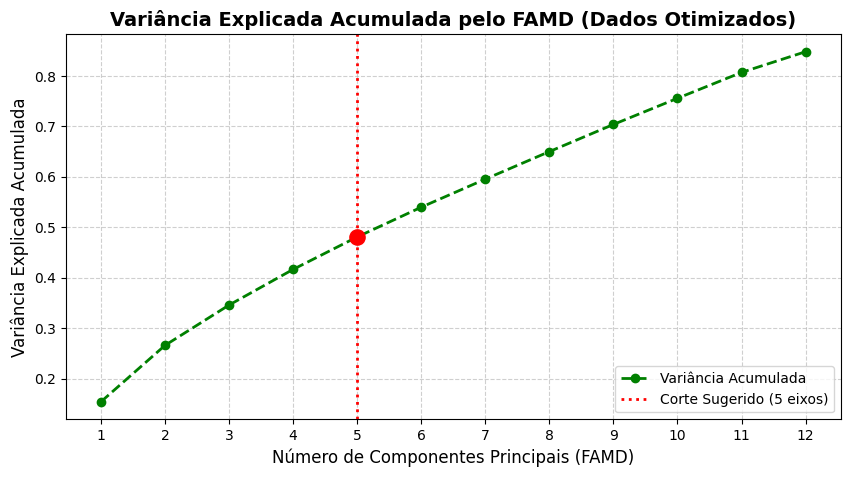

Formato da matriz total gerada pelo FAMD: (94990, 12)


In [24]:
## Passo 3: Análise de Dimensionalidade (FAMD) com Escolha Automatizada
from src.dimensionalidade import aplicar_famd, encontrar_melhor_k_famd, plotar_variancia_famd

# Ajustamos o modelo inicial abrindo espaço para 12 componentes principais mistos
n_componentes_famd = 12
famd_modelo, dados_pca_total = aplicar_famd(df_tratado, features, n_componentes=n_componentes_famd)

# EXECUTANDO A TÉCNICA AUTOMÁTICA: O Python avalia os autovalores e as derivadas de ganho
n_componentes_finais = encontrar_melhor_k_famd(famd_modelo)

# Plota o gráfico exibindo exatamente onde a linha vermelha de corte deve ficar
plotar_variancia_famd(famd_modelo, n_recomendado=n_componentes_finais)

print(f"Formato da matriz total gerada pelo FAMD: {dados_pca_total.shape}")

### Redução para os Componentes Selecionados
Com base no gráfico acima, escolha o número de componentes (ex: 3 componentes) para transformar nossos dados.

In [25]:
# Fatiamos dinamicamente com base no cálculo estatístico automático anterior
dados_pca = dados_pca_total[:, :n_componentes_finais]

print(f"Dados prontos para a clusterização. Novo formato com FAMD: {dados_pca.shape}")
# Irá exibir o corte exato sugerido pelo algoritmo (ex: (94990, 4) ou (94990, 3))

Dados prontos para a clusterização. Novo formato com FAMD: (94990, 5)


## Passo 4: Agrupamento com K-Means
Execução do loop para avaliação de hiperparâmetros (Inércia e Silhueta). Ajuste do modelo final com o `k_escolhido`.

[K-Means] A avaliar métricas de hiperparâmetros...


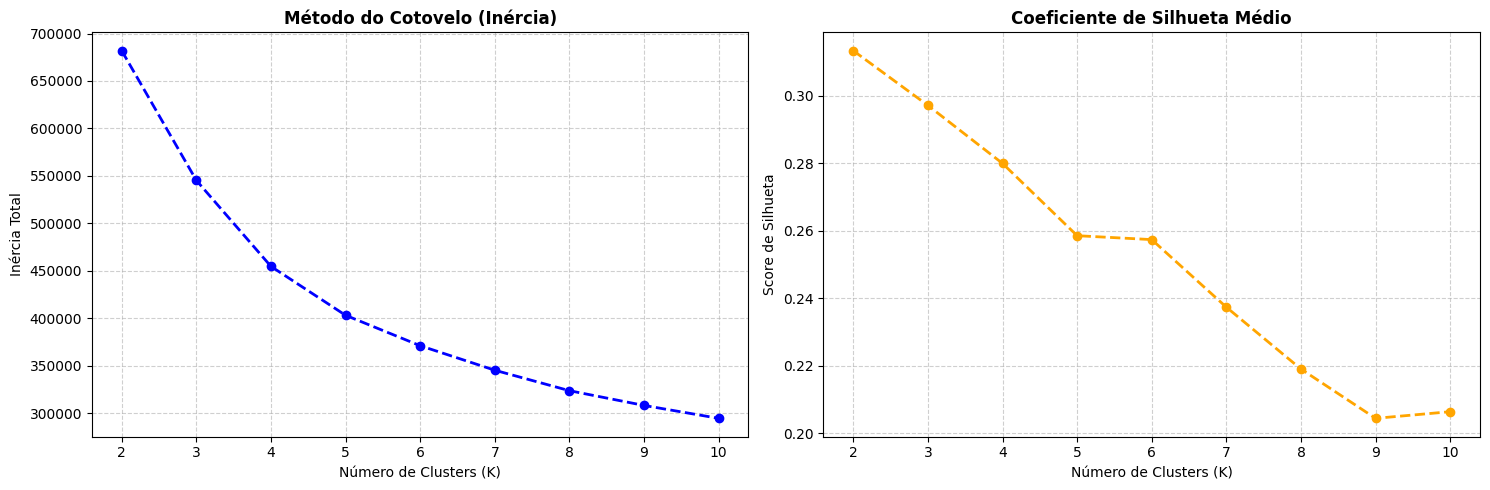

[K-Means] A ajustar o modelo definitivo com K = 4...


In [26]:
# Define o número de clusters a testar para o modelo final
k_clusters = 4

# A função rodará o loop estatístico e plotará os gráficos de validação automaticamente
kmeans_modelo, labels_kmeans = rodar_kmeans(dados_pca, k_max=10, k_escolhido=k_clusters)

# Guardar os resultados no DataFrame principal de clientes
df_clientes['cluster_kmeans'] = labels_kmeans

## Passo 5: Agrupamento com GMM (Gaussian Mixture Models)
Avaliação dos critérios de informação BIC e AIC para escolher o número de componentes probabilísticos.

[GMM] A avaliar curvas de densidade probabilística...


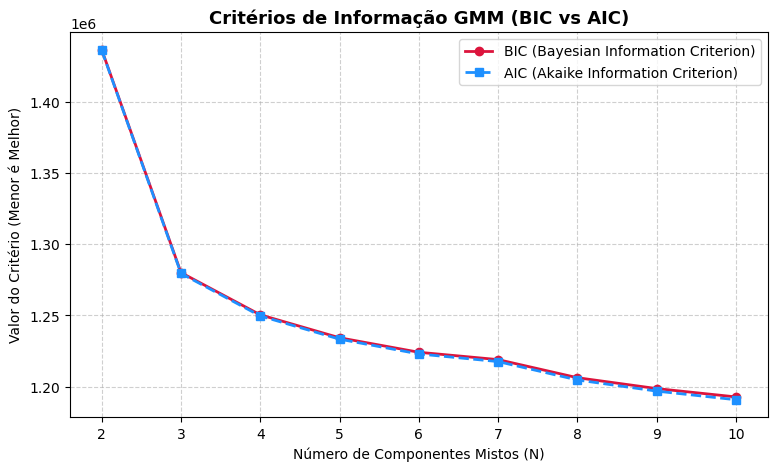

[GMM] A ajustar o modelo definitivo com N = 4...


In [27]:
# Define o número de componentes probabilísticos para o ajuste final
n_componentes_gmm = 4

# A função roda os testes de densidade e renderiza o gráfico AIC/BIC automaticamente
gmm_modelo, labels_gmm = rodar_gmm(dados_pca, n_max=10, n_escolhido=n_componentes_gmm)

# Guardar os rótulos probabilísticos e a certeza do modelo na classificação de cada cliente
df_clientes['cluster_gmm'] = labels_gmm
df_clientes['prob_cluster'] = gmm_modelo.predict_proba(dados_pca).max(axis=1)

## Passo 6: Comparação Estatística entre K-Means e GMM
Análise de cruzamento de grupos (Matriz de Contingência), ARI e NMI para checar a concordância dos dois modelos.

In [28]:
# Esta função cruza as duas colunas criadas e diz o quanto os modelos concordam entre si
comparar_modelos(df_clientes['cluster_kmeans'], df_clientes['cluster_gmm'])


==================== COMPARAÇÃO ESTATÍSTICA DE CONCORDÂNCIA ====================
• Adjusted Rand Index (ARI): 0.4784
• Normalized Mutual Information (NMI): 0.5384
---------------------------------------------------------------------------------
Significado: Valores próximos de 1.0 indicam que os modelos agruparam os mesmos clientes.
Valores próximos de 0.0 indicam que as partições foram feitas de forma independente.

Matriz de Contingência Cruzada (Distribuição de Clientes):
Clusters GMM          0      1      2     3
Clusters K-Means                           
0                     1      0      0  4886
1                  5563  34166      0  1442
2                 17562  10611      1  1528
3                     0      0  15819  3411




## Passo 7: Perfilamento de Negócio
Análise das médias reais de faturamento, recência, frete e avaliações para criar as personas de cada cluster.

In [29]:
print("====== PERFIL DOS CLUSTERS - K-MEANS ======")
perfis_kmeans = analisar_perfis(df_clientes, agrupado_por='cluster_kmeans')
display(perfis_kmeans)

print("\n====== PERFIL DOS CLUSTERS - GMM ======")
perfis_gmm = analisar_perfis(df_clientes, agrupado_por='cluster_gmm')
display(perfis_gmm)

====== PERFIL DOS CLUSTERS - K-MEANS ======


,qtd_clientes,pct_clientes,recencia,frequencia,monetario,parcelas_medias,pct_boleto,pct_cartao_credito,frete_total,review_medio,...,is_sudeste,peso_medio_produtos,qtd_itens_total,gasto_casa_decoracao,gasto_saude_beleza,gasto_esporte_lazer,gasto_tecnologia,gasto_moda_acessorios,cluster_gmm,prob_cluster
cluster_kmeans,,,,,,,,,,,,,,,,,,,,,
0,4887,5.144752,224.363822,1.658277,390.361502,3.630621,0.194446,0.771706,61.369851,3.790894,...,0.712503,2564.113257,2.989155,115.911797,21.934379,26.892329,63.456732,20.402339,2.999386,0.985021
1,41171,43.342457,228.335212,1.000000,85.409022,2.260645,0.000000,0.969736,14.711207,4.316896,...,0.826626,807.258341,1.045080,11.117084,10.678950,8.756848,9.804179,8.687157,0.934930,0.937532
2,29702,31.268555,261.218201,1.000000,264.023463,4.954111,0.001515,0.991078,31.441384,3.874923,...,0.508316,3990.216933,1.127028,43.719952,29.422696,30.525767,13.895672,28.939065,0.511649,0.877111
3,19230,20.244236,253.208684,1.000000,128.603256,1.000000,0.932553,0.000000,20.887400,4.131179,...,0.647634,1867.844366,1.091992,20.783943,12.119810,12.933466,14.496269,8.996675,2.177379,0.986045



====== PERFIL DOS CLUSTERS - GMM ======


,qtd_clientes,pct_clientes,recencia,frequencia,monetario,parcelas_medias,pct_boleto,pct_cartao_credito,frete_total,review_medio,...,is_sudeste,peso_medio_produtos,qtd_itens_total,gasto_casa_decoracao,gasto_saude_beleza,gasto_esporte_lazer,gasto_tecnologia,gasto_moda_acessorios,cluster_kmeans,prob_cluster
cluster_gmm,,,,,,,,,,,,,,,,,,,,,
0,23126,24.345721,235.490573,1.000000,254.831679,5.746346,0.000000,1.000000,29.819536,3.920115,...,0.656274,3460.516028,1.204272,42.603289,30.585780,20.985316,15.693272,29.645814,1.759362,0.878947
1,44777,47.138646,248.183197,1.000000,94.704913,2.141434,0.000000,1.000000,16.591180,4.248587,...,0.709672,1362.002256,1.000335,13.702857,8.209921,13.310540,7.320784,5.619842,1.236974,0.930180
2,15820,16.654385,254.950000,1.000000,112.817020,1.000000,1.000000,0.000000,19.056081,4.176505,...,0.657901,1833.464096,1.000506,17.536625,8.447159,12.275979,11.145798,6.277363,2.999937,0.987384
3,11267,11.861249,224.815656,1.285524,339.090479,2.893037,0.275873,0.464216,45.011914,3.889652,...,0.683856,2678.872325,2.098074,75.100889,39.518665,33.000750,47.767956,40.239878,1.307447,0.961117
